# **Task 3: Advanced Hybrid Segmentation Pipeline**

**Completed Description:**
Apply **Mean Shift filtering** to the input image in order to reduce noise and smooth color regions. Use the output of Mean Shift as input to **the SLIC algorithm** to generate superpixels and form region-based clusters. Utilize the segmented regions from graph clustering to construct **a Region Adjacency Graph (RAG)** and apply **Normalized Cut (or Threshold Cut)** to refine object boundaries and separate overlapping or touching objects.

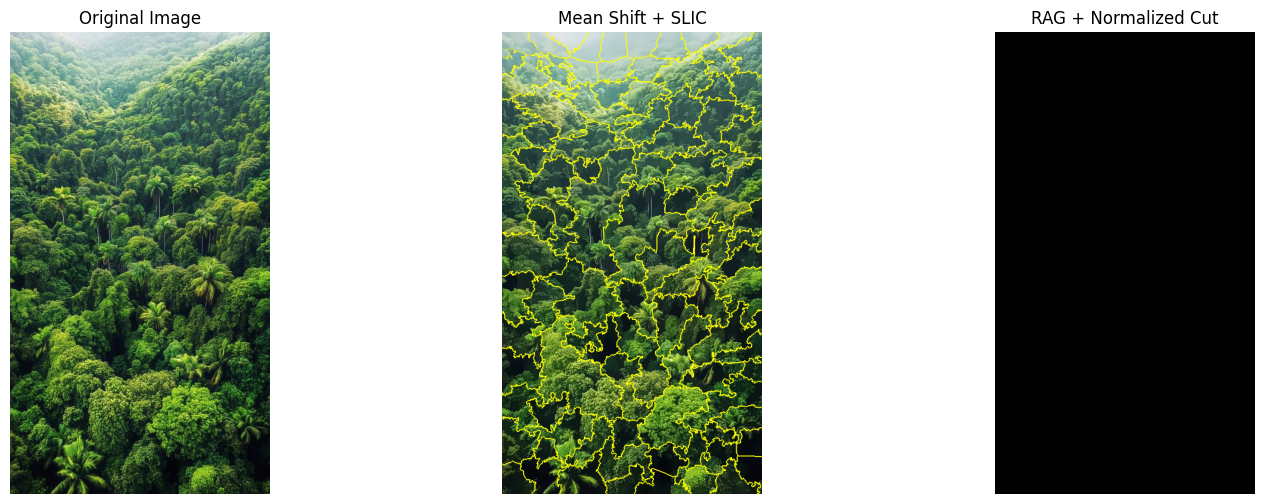

In [1]:
from skimage import io, color
from skimage.segmentation import slic, mark_boundaries
from skimage.graph import rag_mean_color, cut_normalized
import matplotlib.pyplot as plt
import cv2

# 1. Read the image
img = io.imread('dense forest.jpg')

# 2. Apply Mean Shift to reduce noise and smooth color regions
# (spatial window radius = 10, color window radius = 20)
smoothed_img = cv2.pyrMeanShiftFiltering(img, sp=10, sr=20)

# 3. Use output of Mean Shift as input to SLIC
labels_slic = slic(smoothed_img, n_segments=200, compactness=10, start_label=0)

# 4. Construct RAG and apply Normalized Cut
rag = rag_mean_color(smoothed_img, labels_slic)
labels_merged = cut_normalized(labels_slic, rag)
out_final = color.label2rgb(labels_merged, img, kind='avg')

# 5. Display the final pipeline result
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(smoothed_img, labels_slic))
plt.title("Mean Shift + SLIC")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mark_boundaries(out_final, labels_merged))
plt.title("RAG + Normalized Cut")
plt.axis("off")
plt.show()